In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# 차트에 한글 깨지지 않도록 차트 폰트변경
plt.rcParams['font.family'] = 'Malgun Gothic'
# 차트에 "-"문자 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
# 그룹 막대 그래프
df = pd.DataFrame({
    "이름": ["김철수", "이영희", "박민수", "최지영"],
    "성별": ["남", "여", "남", "여"],
    "중간고사": [78, 82, 85, 90],
    "기말고사": [84, 88, 80, 92]
})
df

,이름,성별,중간고사,기말고사
0,김철수,남,78,84
1,이영희,여,82,88
2,박민수,남,85,80
3,최지영,여,90,92


In [4]:
# 전처리 필요 -> 남 / 여 평균
result = df.groupby("성별")[["중간고사", "기말고사"]].mean()
result

,중간고사,기말고사
성별,,
남,81.5,82.0
여,86.0,90.0


<Axes: xlabel='성별'>

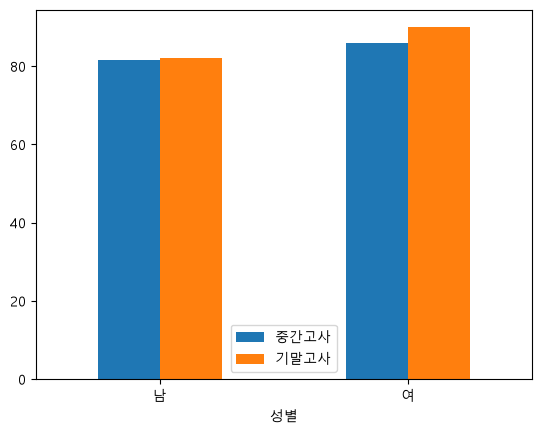

In [6]:
# stacked=False 생략하여도 False로 그룹막대 차트
# stacked=False 이면 누적막대 차트 
result.plot(kind="bar", stacked=False, rot = 0)

In [7]:
# 누적 막대 그래프
data = {
    "이름": ["김민수", "이영희", "박철수", "최지우", "정민호",
           "한지민", "강준호", "윤서연", "오세훈", "임수진",
           "장현우", "김하늘", "이준혁", "박서윤", "최민재",
           "정유진", "한승우", "윤지아", "강민호", "송예린"],
    
    "성별": ["남", "여", "남", "여", "남",
           "여", "남", "여", "남", "여",
           "남", "여", "남", "여", "남",
           "여", "남", "여", "남", "여"],
    
    "반": ["1반", "1반", "1반", "2반", "2반",
         "2반", "3반", "3반", "3반", "1반",
         "1반", "2반", "2반", "3반", "3반",
         "1반", "1반", "2반", "2반", "3반"]
}

df = pd.DataFrame(data)

df

,이름,성별,반
0,김민수,남,1반
1,이영희,여,1반
2,박철수,남,1반
3,최지우,여,2반
4,정민호,남,2반
5,한지민,여,2반
6,강준호,남,3반
7,윤서연,여,3반
8,오세훈,남,3반
9,임수진,여,1반


In [8]:
result = df.groupby(["성별", "반"]).size()
 # size()는 결측치도 포함, count()는 결측치는 카운팅X

result

성별  반 
남   1반    4
    2반    3
    3반    3
여   1반    3
    2반    4
    3반    3
dtype: int64

In [9]:
# "성별·반별 학생 수를 집계한 후, unstack()으로 반을 컬럼으로 펼쳐 시각화하기 좋은 형태로 만든다."
result2 = result.unstack() # df.groupby(["성별", "반"]).size().unstack()
result2

반,1반,2반,3반
성별,,,
남,4,3,3
여,3,4,3


<Axes: xlabel='성별'>

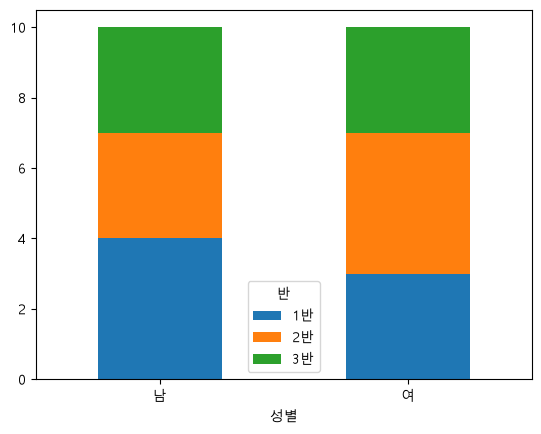

In [10]:
# stacked=False 이면 누적막대 차트 
# stacked=False (생략하면 기본값 False) 그룹막대 차트
result2.plot(kind="bar", stacked=True, rot = 0)

In [11]:
# Boxplot

# --------------------------------------------------
# 학생 성적 데이터 생성
# --------------------------------------------------

data = {
    "이름": [
        "김민준", "이서연", "박지훈", "최지우", "정도윤",
        "강서준", "윤하은", "장현우", "임수빈", "한지민",
        "오준호", "서유진", "신건우", "권예은", "황민재",
        "송채원", "조현준", "배수아", "문지호", "류다은",
        "김도현", "이하윤", "박시우", "최유나", "정우진",
        "강예린", "윤준서", "장서윤", "임도현", "한유진"
    ],

    "성별": [
        "남", "여", "남", "여", "남",
        "남", "여", "남", "여", "여",
        "남", "여", "남", "여", "남",
        "여", "남", "여", "남", "여",
        "남", "여", "남", "여", "남",
        "여", "남", "여", "남", "여"
    ],

    "반": [
        "A", "A", "A", "A", "A",
        "B", "B", "B", "B", "B",
        "A", "A", "A", "A", "A",
        "B", "B", "B", "B", "B",
        "A", "A", "A", "A", "A",
        "B", "B", "B", "B", "B"
    ],

    "학년": [
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        2, 2, 2, 2, 2,
        2, 2, 2, 2, 2,
        3, 3, 3, 3, 3,
        3, 3, 3, 3, 3
    ],

    "중간고사": [
        70, 82, 65, 90, 75,
        88, 72, 80, 95, 68,
        78, 85, 70, 92, 81,
        75, 89, 94, 73, 86,
        83, 91, 77, 96, 72,
        88, 79, 93, 85, 90
    ],

    "기말고사": [
        75, 85, 70, 88, 78,
        92, 76, 84, 97, 73,
        82, 88, 75, 95, 85,
        80, 91, 96, 78, 90,
        87, 94, 81, 98, 76,
        92, 83, 95, 89, 93
    ]
}

df = pd.DataFrame(data)
df

,이름,성별,반,학년,중간고사,기말고사
0,김민준,남,A,1,70,75
1,이서연,여,A,1,82,85
2,박지훈,남,A,1,65,70
3,최지우,여,A,1,90,88
4,정도윤,남,A,1,75,78
5,강서준,남,B,1,88,92
6,윤하은,여,B,1,72,76
7,장현우,남,B,1,80,84
8,임수빈,여,B,1,95,97
9,한지민,여,B,1,68,73


In [12]:
# 데이터 확인
display(df.head())

,이름,성별,반,학년,중간고사,기말고사
0,김민준,남,A,1,70,75
1,이서연,여,A,1,82,85
2,박지훈,남,A,1,65,70
3,최지우,여,A,1,90,88
4,정도윤,남,A,1,75,78


In [13]:
# 행과 열 확인
print(df.shape)

(30, 6)


<Axes: title={'center': '중간고사'}, xlabel='성별'>

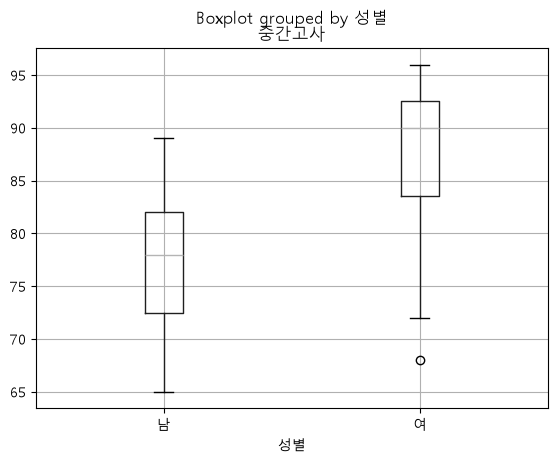

In [14]:
# 남녀 학생의 중간고사 점수 분포 비교

df.boxplot(
    column="중간고사",
    by="성별"
)